# Frequency Response Parameters

In [19]:
import requests as req
try:
    %run basic_material.py
    print('Basic file found')
except:    
    print('Basic not file found - downloading it')
    url = "https://raw.githubusercontent.com/JonHowMIT/Signals_and_Systems/main/basic_material.py"
    res = req.get(url)
    file = open('basic_material.py', 'w')
    file.write(res.text)
    file.close()

import control
import cmath, sympy 
from sympy import Symbol, sqrt, atan
from numpy.polynomial import Polynomial
from numpy.polynomial.polynomial import polyval
from numpy import inf

w = Symbol('w')
wn = Symbol('wn')
z = Symbol('z')
s = sympy.Symbol('s')       # define `s` as symbol

Running Python: 3.8.17
Running Sympy: 1.12
Control Package Found
Basic file found


## Basic Bode Plot

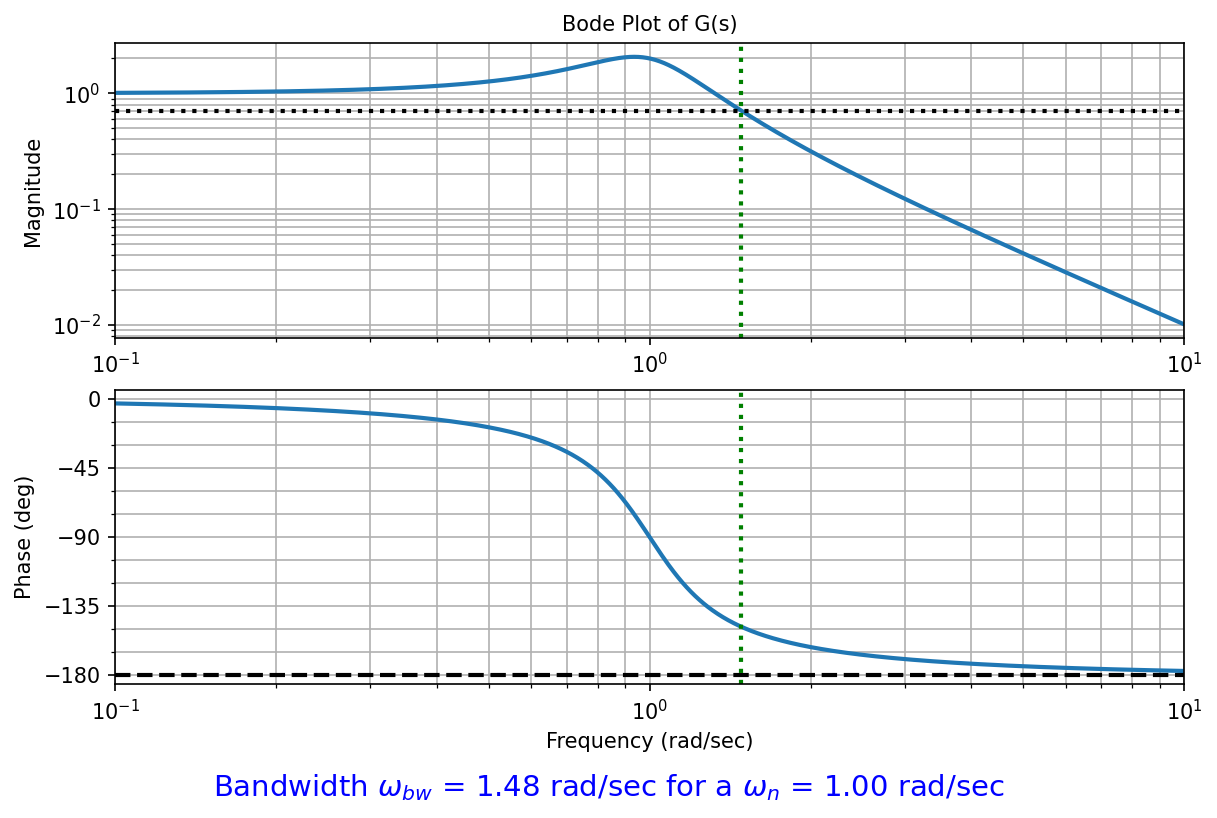

In [20]:
fig, ax = plt.subplots(1,2,figsize=(8, 5),dpi=150,constrained_layout = True)
omega_n = 1
zeta = 0.25
mag_red_for_wb = 1/np.sqrt(2)
G = control.tf([omega_n**2],[1, 2*zeta*omega_n, omega_n**2]) 
Gfreq = control.bode_plot(G,plot=True) #[Gm Gp Gw]
# Bandwidth calc - freq when is magnitude 0.7071?
wb = np.interp(mag_red_for_wb,np.flipud(Gfreq[0]),np.flipud(Gfreq[2]))

ax1,ax2 = plt.gcf().axes
ax1.set_title("Bode Plot of G(s)")
ax1.axhline(y=1/np.sqrt(2),c='k',ls=":")
ax2.axhline(y=-180,c='k',ls="--")
ax1.axvline(x=wb,c='g',ls=":")
ax2.axvline(x=wb,c='g',ls=":")
caption("Bandwidth $\omega_{{bw}}$ = {:4.2f} rad/sec for a $\omega_n$ = {:4.2f} rad/sec".format(wb,omega_n),fig)

# How does the $\omega_c$ and PM depend on $\zeta$?

Consider 
$$
G(s) = \frac{\omega_n^2}{s^2 + 2\zeta \omega_ns + \omega_n^2}
$$
can rewrite this as the unity feedback of the loop 
$ \displaystyle L(s) = \frac{\omega_n^2}{s(s+2\zeta \omega_n)}$ since then
$$
\frac{L}{1+L} = \left(\frac{\omega_n^2}{s(s+2\zeta \omega_n)}\right) / \left(1+\frac{\omega_n^2}{s(s+2\zeta \omega_n)}\right) = \frac{\omega_n^2}{s^2 + 2\zeta \omega_ns + \omega_n^2}
$$

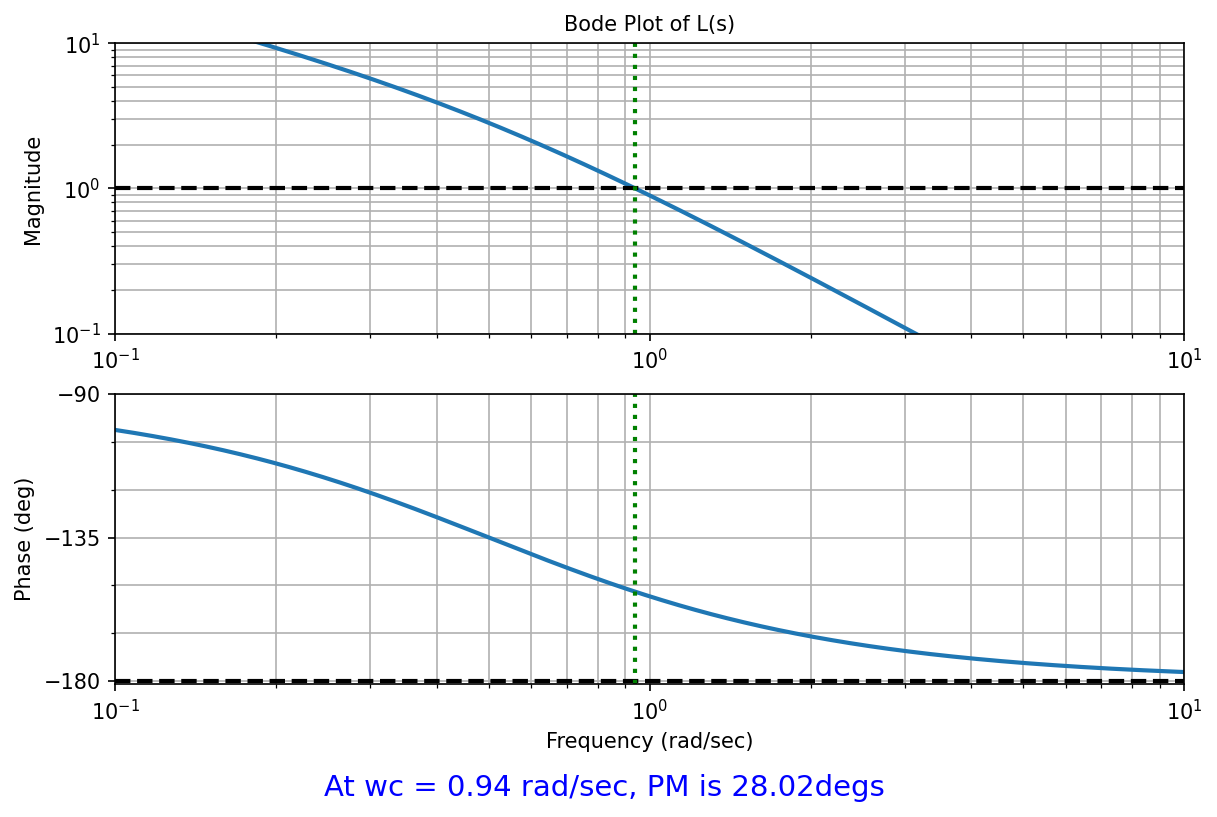

In [21]:
fig, ax = plt.subplots(1,2,figsize=(8, 5),dpi=150,constrained_layout = True)
L = control.tf([omega_n**2],[1, 2*zeta*omega_n, 0]) 
Lfreq = control.bode_plot(L,plot=True) #[Gm Gp Gw]
wc = np.interp(1,np.flipud(Lfreq[0]),np.flipud(Lfreq[2]))
PM = 180+np.interp(wc,Lfreq[2],Lfreq[1])*180/np.pi

ax1,ax2 = plt.gcf().axes
ax1.axhline(y=1,c='k',ls="--")
ax1.set_ylim([.1,10])
ax1.set_title("Bode Plot of L(s)")
ax2.axhline(y=-180,c='k',ls="--")
ax1.axvline(x=wc,c='g',ls=":")
ax2.axvline(x=wc,c='g',ls=":")
caption("At wc = {:4.2f} rad/sec, PM is {:4.2f}degs ".format(wc,PM),fig)

Compute the magnitude of the frequency response of $G(s)$ as
$$ |G(j\omega)| = \frac{1}{\sqrt{(1-(\frac{\omega}{\omega_n})^2)^2 + (\frac{2\zeta\omega}{\omega_n})^2}}
$$
For the frequency of the bandwidth, set this magnitude value to $|G(j\omega_{bw})| \equiv \frac{1}{\sqrt{2}}$

In [22]:
func = ((1-(w/wn)**2)**2+(2*z*w/wn)**2) - 2
sol_wb = sympy.solve(func,w/wn)
sol_wb[3] # multiple solutions - we want the last

sqrt(-2*z**2 + sqrt(2)*sqrt(2*z**4 - 2*z**2 + 1) + 1)

Thus the result is that $\displaystyle \frac{\omega_{bw}}{\omega_n} = \sqrt{1-2\zeta^2 + \sqrt{2 -4\zeta^2(1-\zeta^2)}}$

Continue calculations to note that $\omega_c$ occurs when $|L(j\omega_c)|=1$, where $$ L(j\omega) = \frac{\omega_n^2}{\sqrt{\omega^4 + (2\zeta\omega\omega_n)^2}} = \frac{1}{\sqrt{(\omega/\omega_n)^4 + (2\zeta\omega/\omega_n)^2}} $$ 

In [23]:
func = (w/wn)**4 + (2*z*w/wn)**2 - 1
sol_wc = sympy.solve(func,w/wn)
sol_wc[3] # multiple solutions - we want the last

sqrt(-2*z**2 + sqrt(4*z**4 + 1))

Thus the result is that $\displaystyle \frac{\omega_c}{\omega_n} = \sqrt{\sqrt{4\zeta^4 + 1} - 2\zeta^2}$

In [24]:
f_wc = lambdify((z), sol_wc[3])
f_wb = lambdify((z), sol_wb[3])

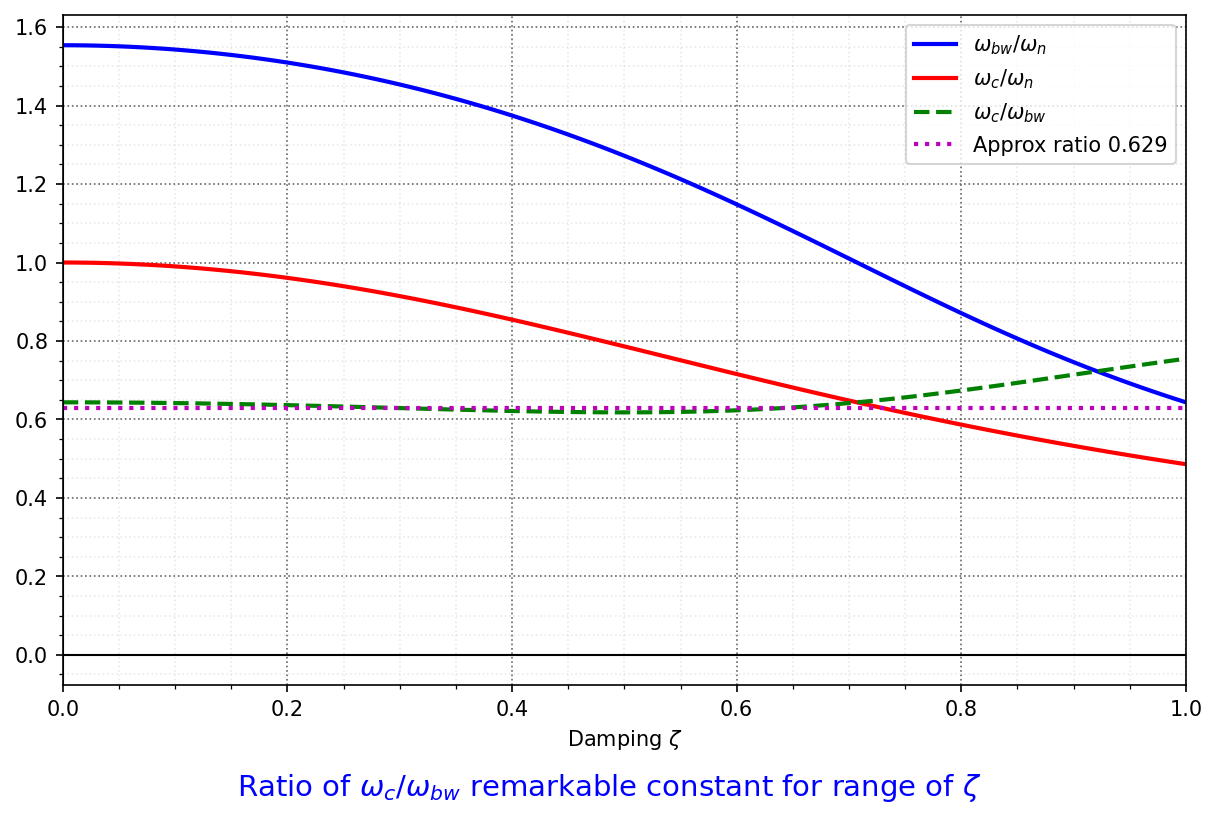

In [25]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
z_range = np.arange(0,1.01,.01)
plt.plot(z_range,f_wb(z_range),'b-',label="$\omega_{bw}/\omega_n$")
plt.plot(z_range,f_wc(z_range),'r-',label="$\omega_c/\omega_n$")
plt.plot(z_range,f_wc(z_range)/f_wb(z_range),'g--',label="$\omega_c/\omega_{bw}$")
plt.axhline(y=f_wc(0.3)/f_wb(0.3),ls=':',color='m',label='Approx ratio {:4.3f}'.format(f_wc(0.3)/f_wb(0.3)))
plt.legend()
nicegrid(ax)
plt.xlabel("Damping $\zeta$")
caption("Ratio of $\omega_c/\omega_{bw}$ remarkable constant for range of $\zeta$ ",fig)
plt.show()

Now consider the phase margin $\phi_m$ at $\omega_c$
$$
\phi_m = 180 - \arctan\left( \frac{2\zeta\omega_n}{-\omega_c} \right) = 180 - \left(180 - \arctan\left( \frac{2\zeta\omega_n}{\omega_c} \right)\right) = \arctan\left( \frac{2\zeta\omega_n}{\omega_c} \right)
$$
where from above, $\displaystyle \frac{\omega_c}{\omega_n} = \sqrt{\sqrt{4\zeta^4 + 1} - 2\zeta^2}$ so
$$
\phi_m = \arctan\left( \frac{2\zeta}{\sqrt{\sqrt{4\zeta^4 + 1} - 2\zeta^2}} \right)
$$


In [26]:
def f_pm(zz): 
    return np.arctan(2*zz/np.sqrt(np.sqrt(4*zz**4+1)-2*zz**2))*180/np.pi

from scipy.optimize import minimize
z_range = np.arange(0,0.707,.001)
def f(xx):
    return np.sum((f_pm(z_range) - float(xx)*z_range)**2)
    
res = minimize(f, 10, method='Nelder-Mead', tol=1e-6)
from IPython.display import display, Latex
display(Latex(f'Optimal PM linear fit = {res.x[0]:6.2f} $\zeta$'))

<IPython.core.display.Latex object>

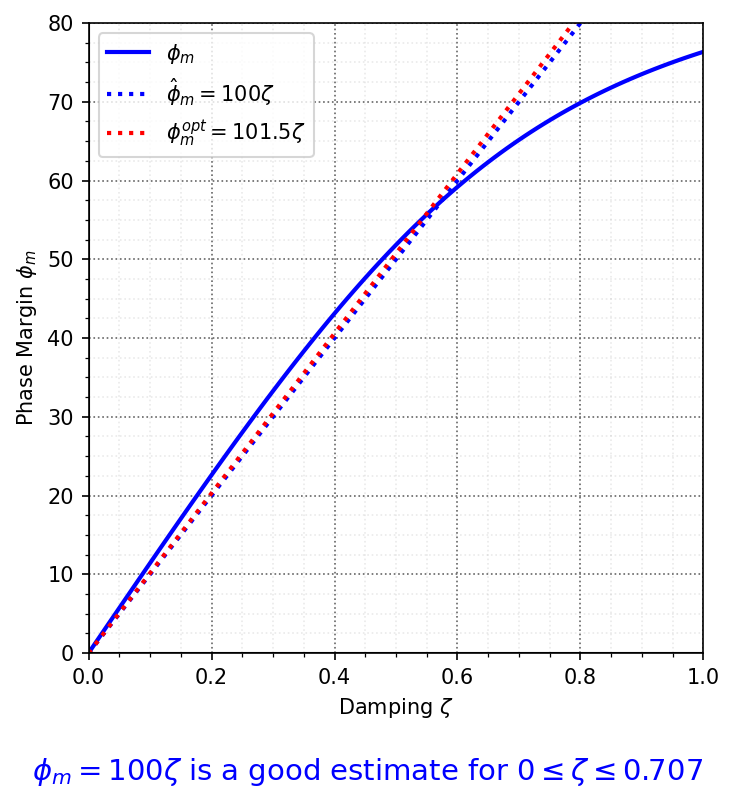

In [42]:
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150)
z_range = np.arange(0,1.01,.01)
plt.plot(z_range,f_pm(z_range),'b-',label="$\phi_m$")
plt.plot([0,1.0],[0,100],'b:',label="$\hat \phi_m = 100 \zeta$")
plt.plot([0,1.0],[0,res.x[0]],'r:',label=r"$\phi_m^{{opt}} = {:5.1f} \zeta$".format(res.x[0]))
plt.ylim([0,80])
nicegrid(ax)
plt.legend()
plt.xlabel("Damping $\zeta$")
plt.ylabel("Phase Margin $\phi_m$")
caption("$\phi_m = 100 \zeta$ is a good estimate for $0\leq \zeta \leq 0.707$",fig)
savefig("./figs/PM_approx.pdf", dpi=600)
plt.show()

To find the peak in the frequency response, set $d|G(j\omega)|/d \omega = 0$

In [28]:
func = 1/sympy.sqrt((1-(w/wn)**2)**2+(2*z*w/wn)**2) 
dfunc = sympy.diff(func,w)
wp = sympy.solve(dfunc,w)
wp[2]

wn*sqrt(1 - 2*z**2)

So the peak frequency is at $\omega_r=\omega_n\sqrt{1-2\zeta^2}$ and the peak magnitude is computed as

In [29]:
Mr = simplify(func.subs(w,wp[2]))

So the height of the resonant peak is $\displaystyle M_r = \frac{1}{2\zeta\sqrt{1-\zeta^2}}$

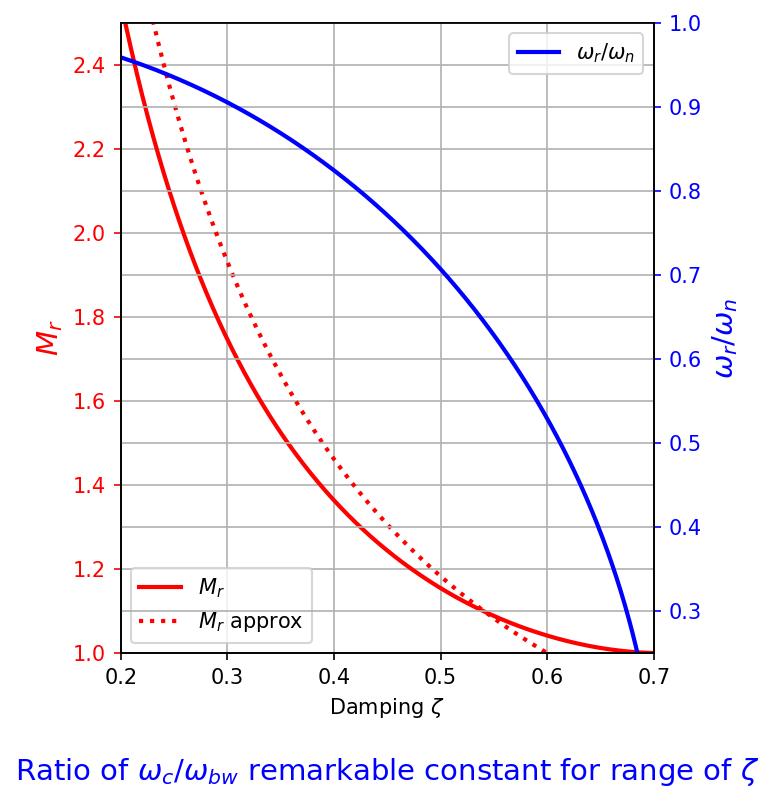

In [44]:
def f_Mr(zz): 
    return 1/(2*zz*np.sqrt(1-zz**2))

def f_wp(zz): 
    return np.sqrt(1-2*zz**2)

COLOR_left = "red"
COLOR_right = "blue"

fig, ax1 = plt.subplots(1,figsize=(5, 5),dpi=150)
ax2 = ax1.twinx()
z_range = np.arange(0.2,0.707,.001)

ax1.plot(z_range,f_Mr(z_range),color=COLOR_left,label="$M_r$")
PM = 100*z_range/r2d
ax1.plot(z_range,1/(2*np.sin(PM/2)),'r:',label='$M_r$ approx')
ax1.legend(loc = 3)
ax2.plot(z_range,f_wp(z_range),color=COLOR_right,label="$\omega_r/\omega_n$")
ax2.legend(loc = 0)
nicegrid(ax)
plt.xlim([0.2,.7])
ax1.set_ylim([1.0,2.5])
ax1.set_ylabel("$M_r$", color=COLOR_left, fontsize=14)
ax1.tick_params(axis='y', colors=COLOR_left)
ax2.tick_params(axis='y', colors=COLOR_right)
ax2.set_ylabel("$\omega_r/\omega_n$", color=COLOR_right, fontsize=14)
ax2.set_ylim([0.25,1])
ax1.set_xlabel("Damping $\zeta$")
caption("Ratio of $\omega_c/\omega_{bw}$ remarkable constant for range of $\zeta$ ",fig)
savefig("./figs/Mr_approx.pdf", dpi=600)
plt.show()


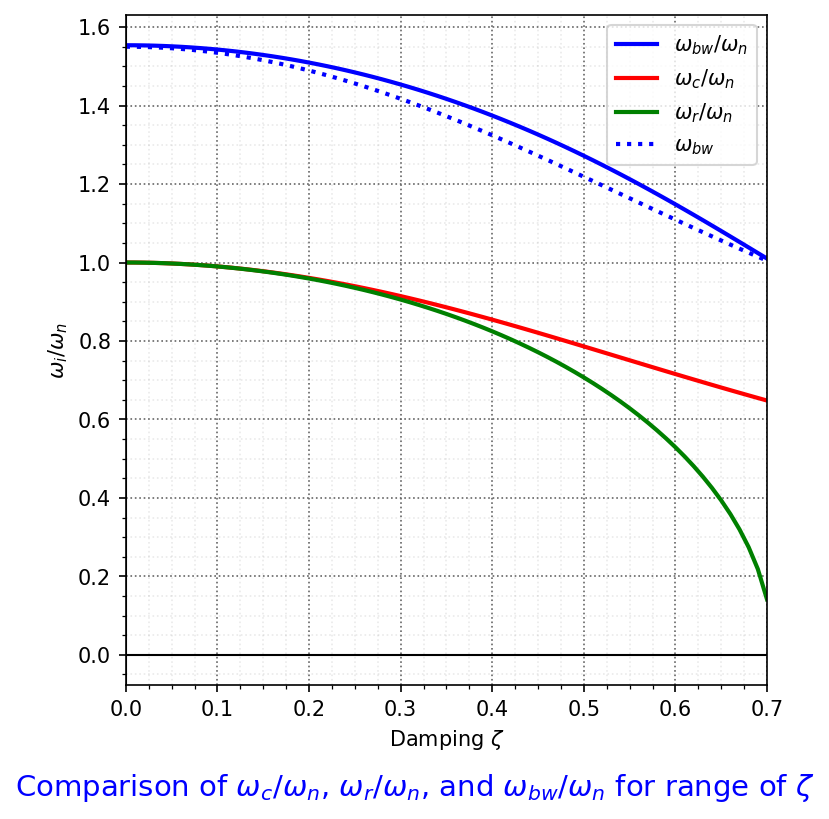

In [45]:
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
z_range = np.arange(0,1/np.sqrt(2),.01)
plt.plot(z_range,f_wb(z_range),'b-',label="$\omega_{bw}/\omega_n$")
plt.plot(z_range,f_wc(z_range),'r-',label="$\omega_c/\omega_n$")
plt.plot(z_range,f_wp(z_range),'g-',label="$\omega_r/\omega_n$")
plt.plot(z_range,1.55*f_wc(z_range),'b:',label="$\omega_{bw} \approx 1.55\omega_c$")
plt.legend()
nicegrid(ax)
plt.xlabel("Damping $\zeta$")
plt.ylabel("$\omega_i/\omega_n$")
caption("Comparison of $\omega_c/\omega_n$, $\omega_r/\omega_n$, and $\omega_{bw}/\omega_n$ for range of $\zeta$",fig)
savefig("./figs/Freqs_approx.pdf", dpi=600)
plt.show()

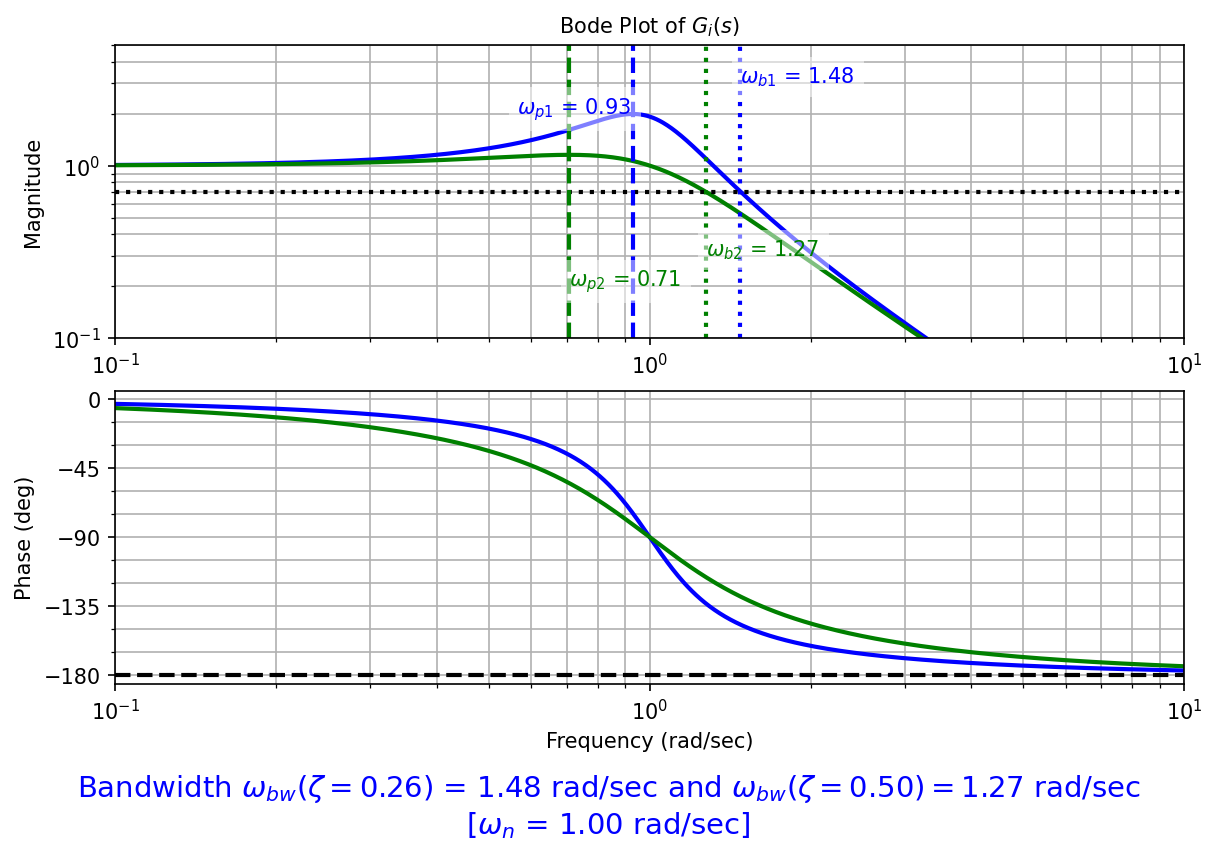

In [39]:
fig, ax = plt.subplots(1,2,figsize=(8, 5),dpi=150,constrained_layout = True)
zeta1 = 0.26
zeta2 = 0.5
kwargs = {'color':'b','linewidth':2}
G1 = control.tf([omega_n**2],[1, 2*zeta1*omega_n, omega_n**2]) 
Gfreq1 = control.bode_plot(G1,plot=True,omega_num=1000,**kwargs) #[Gm Gp Gw]
kwargs = {'color':'g','linewidth':2}
G2 = control.tf([omega_n**2],[1, 2*zeta2*omega_n, omega_n**2]) 
Gfreq2 = control.bode_plot(G2,plot=True,omega_num=1000,**kwargs) #[Gm Gp Gw]

# Bandwidth calc - freq when is magnitude 0.7071?
wb1 = Gfreq1[2][np.argmin((Gfreq1[0] - mag_red_for_wb)**2)]
wb2 = Gfreq2[2][np.argmin((Gfreq2[0] - mag_red_for_wb)**2)]

wp1 = Gfreq1[2][np.argmax(Gfreq1[0])]
wp2 = Gfreq2[2][np.argmax(Gfreq2[0])]

props = dict(facecolor='white', alpha=0.5, linewidth=0)
ax1,ax2 = plt.gcf().axes
ax1.set_title("Bode Plot of $G_i(s)$")
ax1.axhline(y=1/np.sqrt(2),c='k',ls=":")
ax2.axhline(y=-180,c='k',ls="--")
ax1.axvline(x=wb1,c='b',ls=":")
ax1.axvline(x=wp1,c='b',ls="--")
ax1.axvline(x=wb2,c='g',ls=":")
ax1.axvline(x=wp2,c='g',ls="--")
ax1.text(wb1,3,r'$\omega_{{b1}}$ = {:3.2f} '.format(wb1),color='b',bbox=props)
ax1.text(wb2,.3,r'$\omega_{{b2}}$ = {:3.2f} '.format(wb2),color='g',bbox=props)
ax1.text(wp1,2,r'$\omega_{{p1}}$ = {:3.2f} '.format(wp1),color='b',horizontalalignment='right',bbox=props)
ax1.text(wp2,.2,r'$\omega_{{p2}}$ = {:3.2f} '.format(wp2),color='g',bbox=props)
ax1.set_ylim([.1,5])
caption("Bandwidth $\omega_{{bw}}(\zeta={:3.2f})$ = {:4.2f} rad/sec and $\omega_{{bw}}(\zeta={:3.2f})={:4.2f}$ rad/sec\n[$\omega_n$ = {:4.2f} rad/sec]".format(zeta1,wb1,zeta2,wb2,omega_n),fig,yloc=-.1)

# How much Phase?

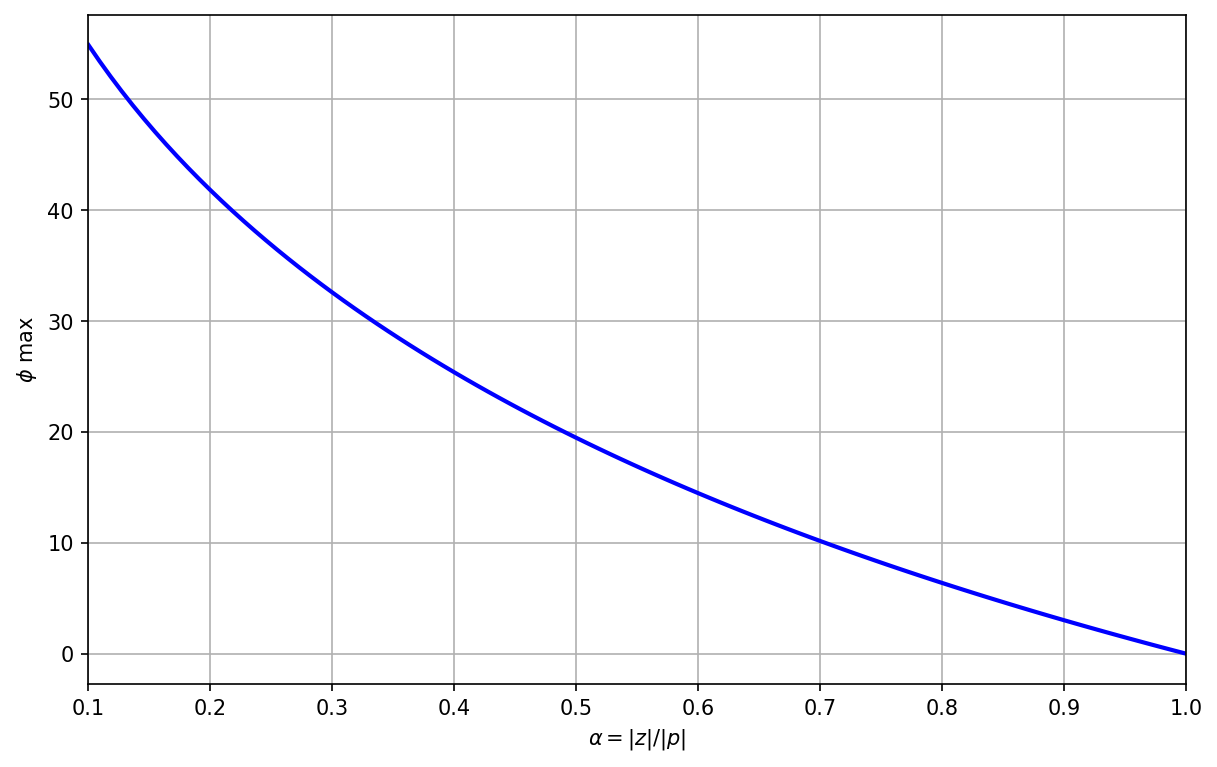

In [57]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
alpha = np.linspace(1/10,1,100)
phi_max = np.arcsin((1-alpha)/(1+alpha))
plt.plot(alpha,phi_max*r2d,'b')
plt.ylabel(r"$\phi$ max")
plt.xlabel(r"$\alpha = |z|/|p|$")
savefig("./figs/How_much_phase.pdf", dpi=600)
plt.show()